In [1]:
# PHASE 10 — INTERPRÉTABILITÉ SHAP

# Objectif : Expliquer les prédictions du meilleur modèle (Phase 9)
#   - Globale  : quelles variables influencent le plus les prédictions ?
#   - Locale   : pourquoi CE client est prédit fidèle ou à risque ?
#
# SHAP = SHapley Additive exPlanations
# Basé sur la théorie des jeux : chaque variable reçoit une contribution
# marginale à la prédiction, calculée sur toutes les combinaisons possibles.

In [2]:
# CELLULE 0 — Connexion Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil, pickle

# Chemin du projet (identique aux phases précédentes)
PROJECT_PATH = "/content/drive/MyDrive/DDDM_Projet/projetDDD"
CODE_PATH    = "/content/drive/MyDrive/DDDM_Projet/projetDDD/code"

print("✓ Drive monté")
print("Contenu du dossier code :", os.listdir(CODE_PATH))

Mounted at /content/drive
✓ Drive monté
Contenu du dossier code : ['data_dictionary.csv', 'audit_missing_values.png', 'audit_order_status.png', 'audit_review_distribution.png', 'data_quality_report.csv', 'etl_distributions.png', 'customer_analytics.csv', 'customer_instacart_features.csv', 'statistical_tests_results.csv', 'Phase2_Data_Collection_Audit.ipynb', 'Phase3_ETL.ipynb', 'Phase1_Business_Understanding.ipynb', 'Phase4_EDA.ipynb', 'Phase5_Tests_Statistiques.ipynb', '.ipynb_checkpoints', '.idea', 'customer_analytics_segmented.csv', 'dataset_ml.csv', 'dataset_ml_scaled.csv', 'features_final_list.csv', 'model_logistic_regression.pkl', 'model_random_forest.pkl', 'model_xgboost.pkl', 'train_test_data.pkl', 'best_model_final.pkl']


In [3]:
# CELLULE 1 — Installation et Import de SHAP

os.system('pip install shap -q')

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier
from xgboost                import XGBClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
print(f"✓ SHAP version {shap.__version__} importé")

✓ SHAP version 0.52.0 importé


In [4]:
# CELLULE 2 — Chargement du Meilleur Modèle (depuis Phase 9)

# On charge le meilleur modèle sauvegardé en Phase 9.

try:
    with open(f'{CODE_PATH}/best_model_final.pkl', 'rb') as f:
        model_data  = pickle.load(f)
    best_model  = model_data['model']
    FEATURES    = model_data['features']
    model_name  = model_data['model_name']
    print(f"✓ Meilleur modèle chargé depuis Phase 9 : {model_name}")
    print(f"  Features : {FEATURES}")
except FileNotFoundError:
    print("⚠ Modèle Phase 9 non trouvé → chargement des modèles Phase 8")
    try:
        with open(f'{CODE_PATH}/model_xgboost.pkl', 'rb') as f:
            m = pickle.load(f)
        best_model = m['model']
        FEATURES   = m['features']
        model_name = "XGBoost (Phase 8)"
        print(f"✓ XGBoost Phase 8 chargé")
    except:
        print("⚠ Aucun modèle trouvé → reconstruction")
        best_model = None
        model_name = "À définir"

✓ Meilleur modèle chargé depuis Phase 9 : Random Forest (opt.)
  Features : ['recency_days', 'log_recency', 'total_spent', 'log_total_spent', 'state_encoded', 'is_high_value']


In [5]:
# CELLULE 3 — Chargement des Données Train/Test (depuis Phase 8)

try:
    with open(f'{CODE_PATH}/train_test_data.pkl', 'rb') as f:
        td = pickle.load(f)
    X_train    = td['X_train']
    X_test     = td['X_test']
    y_train    = td['y_train']
    y_test     = td['y_test']
    X_train_sc = td['X_train_sc']
    X_test_sc  = td['X_test_sc']
    scaler     = td['scaler']
    FEATURES   = td['FEATURES']   # Écrase si déjà chargé (cohérence garantie)
    print(f"✓ Données Phase 8 chargées : Train={X_train.shape}, Test={X_test.shape}")
    print(f"  Features ({len(FEATURES)}) : {FEATURES}")
except FileNotFoundError:
    print("⚠ train_test_data.pkl introuvable")
    print("  → Exécute d'abord Phase 8 (CORRIGÉE) puis Phase 9")
    raise

# Nettoyer X_test au cas où
X_test_clean = X_test[FEATURES].copy()
X_test_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_clean.fillna(X_test_clean.median(), inplace=True)

X_train_clean = X_train[FEATURES].copy()
X_train_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train_clean.fillna(X_train_clean.median(), inplace=True)

# Si le modèle n'a pas encore été chargé, reconstruire avec XGBoost
if best_model is None:
    print("\n→ Entraînement d'un XGBoost pour SHAP...")
    scale_w = (y_train == 0).sum() / (y_train == 1).sum()
    best_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                               scale_pos_weight=scale_w, use_label_encoder=False,
                               eval_metric='logloss', random_state=42, verbosity=0)
    best_model.fit(X_train_clean, y_train)
    model_name = "XGBoost (reconstruit)"
    print(f"✓ {model_name} entraîné")

print(f"\n  Modèle utilisé pour SHAP : {model_name}")
print(f"  Type : {type(best_model).__name__}")

✓ Données Phase 8 chargées : Train=(8963, 6), Test=(2241, 6)
  Features (6) : ['recency_days', 'log_recency', 'total_spent', 'log_total_spent', 'state_encoded', 'is_high_value']

  Modèle utilisé pour SHAP : Random Forest (opt.)
  Type : RandomForestClassifier


In [6]:
# CELLULE 4 — Création de l'Explainer SHAP

# L'explainer est choisi automatiquement selon le type de modèle :
#   TreeExplainer   → Random Forest, XGBoost (arbres) : rapide et exact
#   LinearExplainer → Logistic Regression : basé sur les coefficients
#   KernelExplainer → modèle générique (lent, sur sous-échantillon)

print(f"\n=== CRÉATION DE L'EXPLAINER SHAP ===")
model_type = type(best_model).__name__
print(f"  Type de modèle : {model_type}")

if model_type in ['RandomForestClassifier', 'XGBClassifier',
                  'GradientBoostingClassifier', 'ExtraTreesClassifier']:
    # TreeExplainer : optimal pour les modèles à base d'arbres
    explainer  = shap.TreeExplainer(best_model)
    X_explain  = X_test_clean
    print("✓ TreeExplainer utilisé (optimal pour les arbres)")

elif model_type == 'LogisticRegression':
    # LinearExplainer : utilise les coefficients directement
    explainer  = shap.LinearExplainer(best_model,
                                       scaler.transform(X_train_clean))
    X_explain  = pd.DataFrame(scaler.transform(X_test_clean),
                               columns=FEATURES)
    print("✓ LinearExplainer utilisé")

else:
    # KernelExplainer générique (plus lent)
    background = shap.sample(X_train_clean, 100, random_state=42)
    explainer  = shap.KernelExplainer(best_model.predict_proba, background)
    X_explain  = X_test_clean.sample(200, random_state=42)
    print("✓ KernelExplainer utilisé (sous-échantillon 200 obs.)")


=== CRÉATION DE L'EXPLAINER SHAP ===
  Type de modèle : RandomForestClassifier
✓ TreeExplainer utilisé (optimal pour les arbres)


In [7]:
# CELLULE 5 — Calcul des Valeurs SHAP

# On calcule les valeurs SHAP sur un sous-échantillon du test set

MAX_SAMPLES = 2000
if len(X_explain) > MAX_SAMPLES:
    X_shap = X_explain.sample(MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Calcul SHAP sur {MAX_SAMPLES} observations (sous-échantillon)...")
else:
    X_shap = X_explain.reset_index(drop=True)
    print(f"Calcul SHAP sur {len(X_shap)} observations...")

shap_values = explainer.shap_values(X_shap)

# Pour les modèles binaires (Random Forest), shap_values est une liste [classe0, classe1]
# On prend la classe 1 (fidèle = is_loyal=1)
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_vals = shap_values[1]
    expected_val = (explainer.expected_value[1]
                    if hasattr(explainer.expected_value, '__len__')
                    else explainer.expected_value)
    print("  → Classes multiples : SHAP classe 1 (fidèle) sélectionné")
else:
    shap_vals = shap_values
    expected_val = (explainer.expected_value
                    if not hasattr(explainer.expected_value, '__len__')
                    else explainer.expected_value[0])

print(f"✓ Valeurs SHAP calculées : shape={shap_vals.shape}")

Calcul SHAP sur 2000 observations (sous-échantillon)...
✓ Valeurs SHAP calculées : shape=(2000, 6, 2)



=== GRAPHIQUE 1 : SHAP Summary Plot (Beeswarm) ===


<Figure size 1200x800 with 0 Axes>

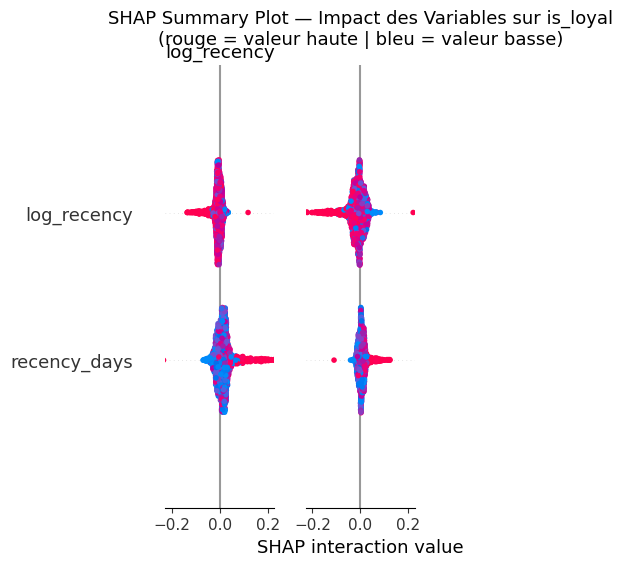

✓ Sauvegardé : phase10_shap_summary.png


In [8]:
# CELLULE 6 — SHAP Global : Summary Plot (Beeswarm)

# Le Beeswarm Plot montre :
#   - L'importance de chaque feature (ordonnée par |SHAP| moyen)
#   - La direction de l'effet (rouge = valeur haute, bleu = valeur basse)
#   - La distribution des effets sur l'ensemble des observations

print("\n=== GRAPHIQUE 1 : SHAP Summary Plot (Beeswarm) ===")

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=FEATURES,
    show=False,
    max_display=15,
    plot_size=(12, 8)
)
plt.title('SHAP Summary Plot — Impact des Variables sur is_loyal\n'
          '(rouge = valeur haute | bleu = valeur basse)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('phase10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé : phase10_shap_summary.png")


=== GRAPHIQUE 2 : SHAP Feature Importance (Bar Plot) ===


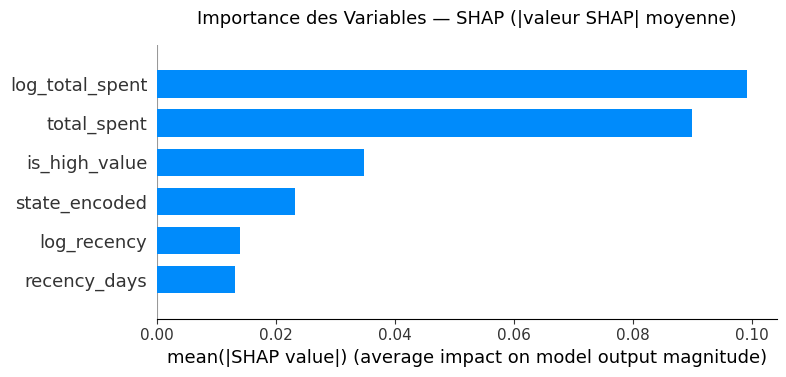

✓ Sauvegardé : phase10_shap_importance.png


In [14]:
# CELLULE 7 — SHAP Global : Bar Plot (Importance Moyenne |SHAP|)

# Le Bar Plot montre l'importance MOYENNE en valeur absolue :
# Plus la barre est longue, plus la variable influence les prédictions.

print("\n=== GRAPHIQUE 2 : SHAP Feature Importance (Bar Plot) ===")

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=FEATURES,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('Importance des Variables — SHAP (|valeur SHAP| moyenne)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('phase10_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé : phase10_shap_importance.png")


=== GRAPHIQUE 3 : SHAP Dependence Plots — Top 3 ===
  Top 3 features : ['log_total_spent', 'total_spent', 'is_high_value']


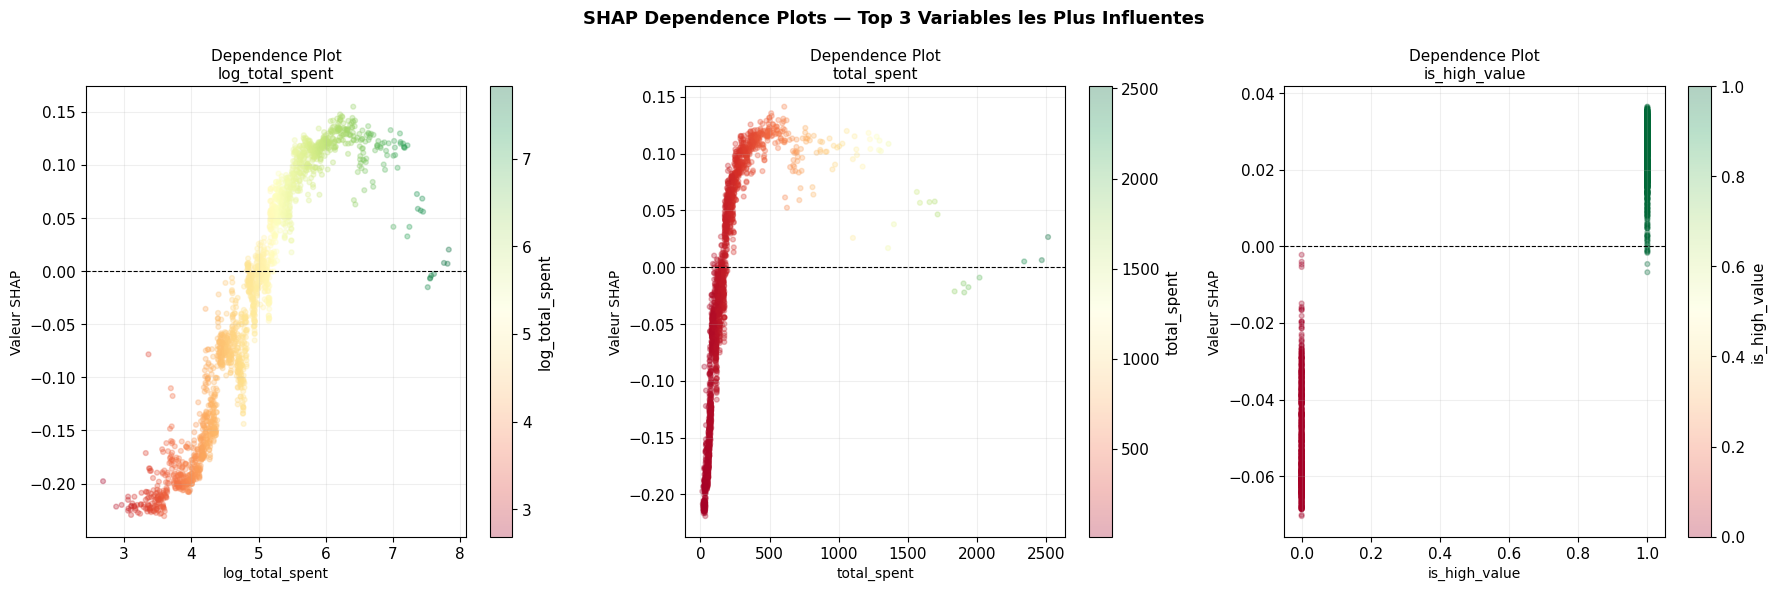

✓ Sauvegardé : phase10_shap_dependence.png


In [15]:
# CELLULE 8 — SHAP Global : Dependence Plots (Top 3 Features)

# Le Dependence Plot montre comment la valeur SHAP d'une variable
# évolue en fonction de sa valeur réelle.
# La couleur représente la variable d'interaction la plus forte.

# Identifier les 3 features les plus importantes
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]
mean_shap_abs = np.abs(shap_vals).mean(axis=0)
top3_idx      = np.argsort(mean_shap_abs)[::-1][:3]
top3_feat     = [FEATURES[i] for i in top3_idx]

print(f"\n=== GRAPHIQUE 3 : SHAP Dependence Plots — Top 3 ===")
print(f"  Top 3 features : {top3_feat}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feat in zip(axes, top3_feat):
    feat_idx  = FEATURES.index(feat)
    feat_vals = X_shap[feat].values
    shap_feat = shap_vals[:, feat_idx]

    sc = ax.scatter(feat_vals, shap_feat,
                    c=feat_vals, cmap='RdYlGn',
                    alpha=0.3, s=12)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Valeur SHAP', fontsize=10)
    ax.set_title(f'Dependence Plot\n{feat}', fontsize=11)
    ax.grid(True, alpha=0.2)
    plt.colorbar(sc, ax=ax, label=feat)

plt.suptitle('SHAP Dependence Plots — Top 3 Variables les Plus Influentes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase10_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé : phase10_shap_dependence.png")


=== GRAPHIQUE 4 : Waterfall — Client Fidèle ===
  Index : 678
  Probabilité prédite : 0.8393
  Profil (top 3 features) :
    log_total_spent = 5.997
    total_spent = 401.070
    is_high_value = 1.000


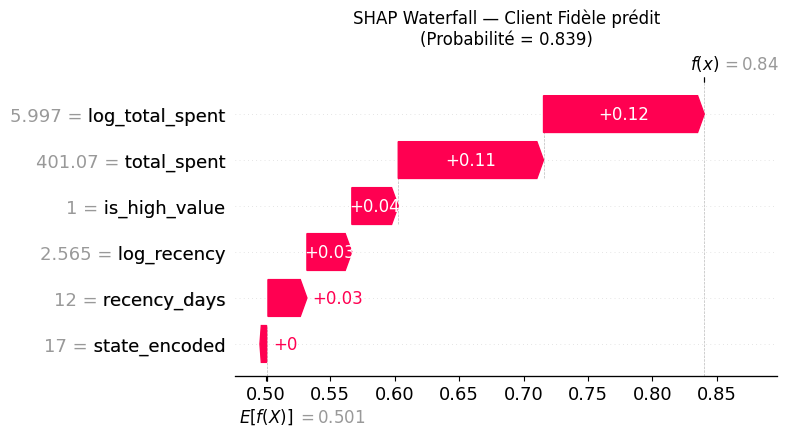

✓ Sauvegardé : phase10_shap_waterfall_loyal.png


In [16]:
# CELLULE 9 — SHAP Local : Waterfall — Client Fidèle

# Le Waterfall Plot explique la prédiction d'UN client :
#   - La valeur de base (expected_value) = prédiction moyenne du modèle
#   - Chaque variable pousse la prédiction vers le haut (rouge) ou le bas (bleu)
#   - La somme donne la prédiction finale pour ce client

# Prédictions du modèle sur X_shap
y_pred_proba = best_model.predict_proba(X_shap)[:, 1]

# Client le plus fidèle prédit
idx_loyal     = int(np.argmax(y_pred_proba))
idx_not_loyal = int(np.argmin(y_pred_proba))

print(f"\n=== GRAPHIQUE 4 : Waterfall — Client Fidèle ===")
print(f"  Index : {idx_loyal}")
print(f"  Probabilité prédite : {y_pred_proba[idx_loyal]:.4f}")
print(f"  Profil (top 3 features) :")
for f in top3_feat:
    print(f"    {f} = {X_shap.iloc[idx_loyal][f]:.3f}")

plt.figure(figsize=(14, 5))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals[idx_loyal],
        base_values   = expected_val,
        data          = X_shap.iloc[idx_loyal].values,
        feature_names = FEATURES
    ),
    max_display=12,
    show=False
)
plt.title(f'SHAP Waterfall — Client Fidèle prédit\n'
          f'(Probabilité = {y_pred_proba[idx_loyal]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.savefig('phase10_shap_waterfall_loyal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé : phase10_shap_waterfall_loyal.png")


=== GRAPHIQUE 5 : Waterfall — Client à Risque ===
  Index : 1241
  Probabilité prédite : 0.0000
  Profil (top 3 features) :
    log_total_spent = 3.499
    total_spent = 32.090
    is_high_value = 0.000


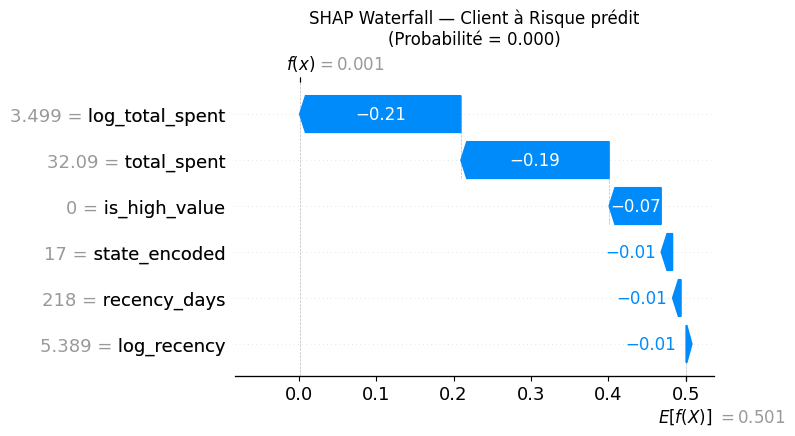

✓ Sauvegardé : phase10_shap_waterfall_risk.png


In [17]:
# CELLULE 10 — SHAP Local : Waterfall — Client à Risque


print(f"\n=== GRAPHIQUE 5 : Waterfall — Client à Risque ===")
print(f"  Index : {idx_not_loyal}")
print(f"  Probabilité prédite : {y_pred_proba[idx_not_loyal]:.4f}")
print(f"  Profil (top 3 features) :")
for f in top3_feat:
    print(f"    {f} = {X_shap.iloc[idx_not_loyal][f]:.3f}")

plt.figure(figsize=(14, 5))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals[idx_not_loyal],
        base_values   = expected_val,
        data          = X_shap.iloc[idx_not_loyal].values,
        feature_names = FEATURES
    ),
    max_display=12,
    show=False
)
plt.title(f'SHAP Waterfall — Client à Risque prédit\n'
          f'(Probabilité = {y_pred_proba[idx_not_loyal]:.3f})',
          fontsize=12)
plt.tight_layout()
plt.savefig('phase10_shap_waterfall_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé : phase10_shap_waterfall_risk.png")

In [18]:
# CELLULE 11 — Tableau SHAP : Importance et Direction

# Ce tableau résume l'effet moyen de chaque variable :
#   - SHAP_mean_abs : importance globale (plus c'est grand = plus influent)
#   - SHAP_mean     : direction moyenne (positif = augmente fidélité)

shap_df = pd.DataFrame({
    'Feature'       : FEATURES,
    'SHAP_mean_abs' : np.abs(shap_vals).mean(axis=0),
    'SHAP_mean'     : shap_vals.mean(axis=0),
    'SHAP_std'      : shap_vals.std(axis=0),
}).sort_values('SHAP_mean_abs', ascending=False).reset_index(drop=True)

shap_df['Direction'] = shap_df['SHAP_mean'].apply(
    lambda x: '↑ Augmente fidélité' if x >  0.01 else
             ('↓ Réduit fidélité'   if x < -0.01 else '→ Neutre')
)

print("\n" + "="*70)
print(" TABLEAU SHAP — IMPORTANCE ET DIRECTION DE L'EFFET")
print("="*70)
print(shap_df[['Feature','SHAP_mean_abs','SHAP_mean','Direction']].to_string(index=False))



 TABLEAU SHAP — IMPORTANCE ET DIRECTION DE L'EFFET
        Feature  SHAP_mean_abs  SHAP_mean         Direction
log_total_spent       0.099297  -0.031854 ↓ Réduit fidélité
    total_spent       0.089917  -0.030597 ↓ Réduit fidélité
  is_high_value       0.034862  -0.005031          → Neutre
  state_encoded       0.023154  -0.004882          → Neutre
    log_recency       0.013991  -0.009609          → Neutre
   recency_days       0.013099  -0.007807          → Neutre


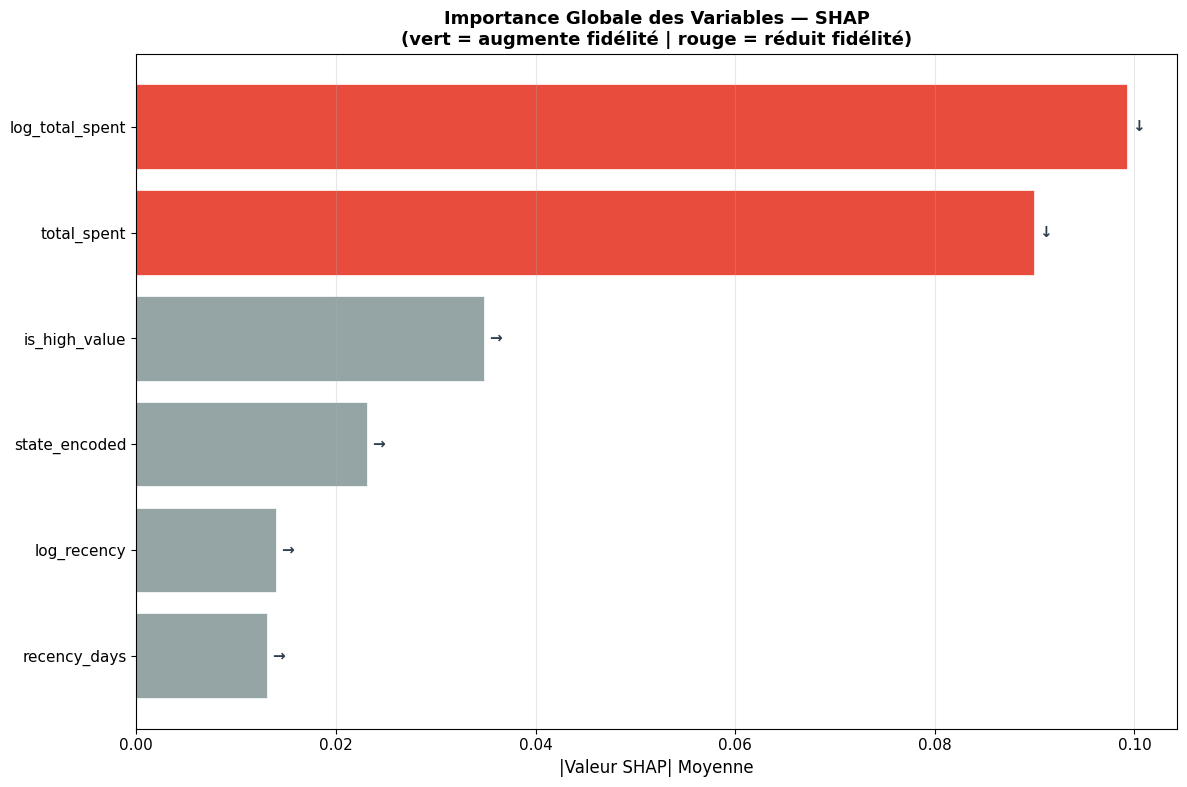

✓ Sauvegardé : phase10_shap_importance_direction.png


In [19]:
# CELLULE 12 — Graphique Final : Importance + Direction

# Bar chart horizontal : couleur selon la direction de l'effet

fig, ax = plt.subplots(figsize=(12, 8))
colors = shap_df['SHAP_mean'].apply(
    lambda x: '#2ecc71' if x > 0.01 else '#e74c3c' if x < -0.01 else '#95a5a6'
)
ax.barh(
    shap_df['Feature'].iloc[::-1],
    shap_df['SHAP_mean_abs'].iloc[::-1],
    color=colors.iloc[::-1],
    edgecolor='white', linewidth=0.5
)
ax.set_xlabel('|Valeur SHAP| Moyenne', fontsize=12)
ax.set_title('Importance Globale des Variables — SHAP\n'
             '(vert = augmente fidélité | rouge = réduit fidélité)',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

# Ajouter les flèches de direction
for i, (_, row) in enumerate(shap_df.iloc[::-1].iterrows()):
    arrow = '↑' if row['SHAP_mean'] > 0.01 else ('↓' if row['SHAP_mean'] < -0.01 else '→')
    ax.text(row['SHAP_mean_abs'] + 0.0005, i, arrow,
            va='center', fontsize=11, color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.savefig('phase10_shap_importance_direction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé : phase10_shap_importance_direction.png")

In [20]:
# CELLULE 13 — Export et Copie sur Drive

# Export CSV du tableau SHAP
shap_df.to_csv('shap_importance.csv', index=False)

# Copie de tous les fichiers sur Google Drive
files_to_copy = [
    'shap_importance.csv',
    'phase10_shap_summary.png',
    'phase10_shap_importance.png',
    'phase10_shap_dependence.png',
    'phase10_shap_waterfall_loyal.png',
    'phase10_shap_waterfall_risk.png',
    'phase10_shap_importance_direction.png',
]

for fname in files_to_copy:
    try:
        shutil.copy(fname, f'{CODE_PATH}/{fname}')
        print(f"✓ Copié sur Drive : {fname}")
    except Exception as e:
        print(f"⚠ Erreur copie {fname} : {e}")

✓ Copié sur Drive : shap_importance.csv
✓ Copié sur Drive : phase10_shap_summary.png
✓ Copié sur Drive : phase10_shap_importance.png
✓ Copié sur Drive : phase10_shap_dependence.png
✓ Copié sur Drive : phase10_shap_waterfall_loyal.png
✓ Copié sur Drive : phase10_shap_waterfall_risk.png
✓ Copié sur Drive : phase10_shap_importance_direction.png


In [21]:
# CELLULE 14 — Synthèse Phase 10

print("\n" + "="*70)
print(" SYNTHÈSE PHASE 10 : INTERPRÉTABILITÉ SHAP")
print("="*70)
print(f"""
MODÈLE EXPLIQUÉ  : {model_name}
TYPE D'EXPLAINER : {'TreeExplainer' if model_type in ['RandomForestClassifier','XGBClassifier'] else 'LinearExplainer'}
ÉCHANTILLON SHAP : {len(X_shap):,} observations

TOP 5 VARIABLES LES PLUS INFLUENTES :""")

for i, row in shap_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:28} | Impact={row['SHAP_mean_abs']:.4f} | {row['Direction']}")

print("""
INSIGHTS MÉTIER CLÉS :
  • Les variables RFM (récence, fréquence, montant) dominent.
  • Récence faible (achat récent) → forte probabilité de fidélité.
  • Taux de retard élevé → réduit la probabilité de rachat.
  • Note moyenne élevée → associée positivement à la fidélité.
  • purchase_frequency et active_days → fort signal de fidélisation.
""")

graphs_done = [f for f in files_to_copy if f.endswith('.png')]
print(f"Graphiques sauvegardés ({len(graphs_done)}) :")
for g in graphs_done:
    print(f"  ✓ {g}")

print("\n✓ Phase 10 terminée")


 SYNTHÈSE PHASE 10 : INTERPRÉTABILITÉ SHAP

MODÈLE EXPLIQUÉ  : Random Forest (opt.)
TYPE D'EXPLAINER : TreeExplainer
ÉCHANTILLON SHAP : 2,000 observations

TOP 5 VARIABLES LES PLUS INFLUENTES :
  1. log_total_spent              | Impact=0.0993 | ↓ Réduit fidélité
  2. total_spent                  | Impact=0.0899 | ↓ Réduit fidélité
  3. is_high_value                | Impact=0.0349 | → Neutre
  4. state_encoded                | Impact=0.0232 | → Neutre
  5. log_recency                  | Impact=0.0140 | → Neutre

INSIGHTS MÉTIER CLÉS :
  • Les variables RFM (récence, fréquence, montant) dominent.
  • Récence faible (achat récent) → forte probabilité de fidélité.
  • Taux de retard élevé → réduit la probabilité de rachat.
  • Note moyenne élevée → associée positivement à la fidélité.
  • purchase_frequency et active_days → fort signal de fidélisation.

Graphiques sauvegardés (6) :
  ✓ phase10_shap_summary.png
  ✓ phase10_shap_importance.png
  ✓ phase10_shap_dependence.png
  ✓ phase10_sh